# sentiPlus – Hybrid Sentiment Analysis System

## Objective
To classify product reviews into Positive, Negative, and Neutral sentiments using a hybrid approach combining SVM and VADER.

In [24]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

from wordcloud import WordCloud

In [25]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/varunarvind/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/varunarvind/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/varunarvind/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/varunarvind/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [26]:
df = pd.read_csv("product_reviews.csv")

df.head()

,Text,Label,Window,User Name,User ID
0,"It works as described, no major issues.",Neutral,Flipkart,Arjun Singh,U1001
1,Customer service was unhelpful and rude.,Negative,Flipkart,Vikram Joshi,U1002
2,"Amazing quality, totally worth the price.",Positive,Flipkart,Ananya Roy,U1003
3,"I am very satisfied with my purchase, highly r...",Positive,Flipkart,Vikram Joshi,U1004
4,"I am disappointed, it did not meet my expectat...",Negative,Flipkart,Raj Verma,U1005


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Text       1000 non-null   str  
 1   Label      1000 non-null   str  
 2   Window     1000 non-null   str  
 3   User Name  1000 non-null   str  
 4   User ID    1000 non-null   str  
dtypes: str(5)
memory usage: 113.0 KB


In [28]:
df.shape

(1000, 5)

In [29]:
# Remove null values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove tiny junk reviews
df = df[df['Text'].str.strip().str.len() > 3]

# Keep reviews with at least 2 words
df = df[df['Text'].str.split().apply(len) >= 2]

df.shape

(1000, 5)

In [30]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [31]:
df['cleaned'] = df['Text'].apply(preprocess)

df[['Text', 'cleaned']].head()

,Text,cleaned
0,"It works as described, no major issues.",work described major issue
1,Customer service was unhelpful and rude.,customer service unhelpful rude
2,"Amazing quality, totally worth the price.",amazing quality totally worth price
3,"I am very satisfied with my purchase, highly r...",satisfied purchase highly recommend
4,"I am disappointed, it did not meet my expectat...",disappointed meet expectation


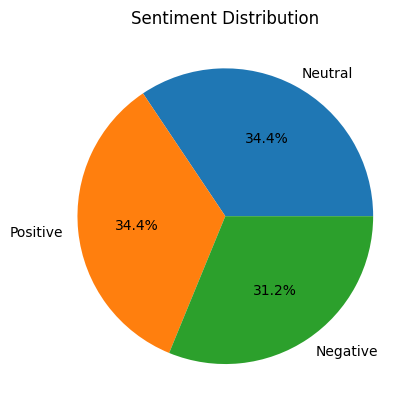

In [32]:
df['Label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

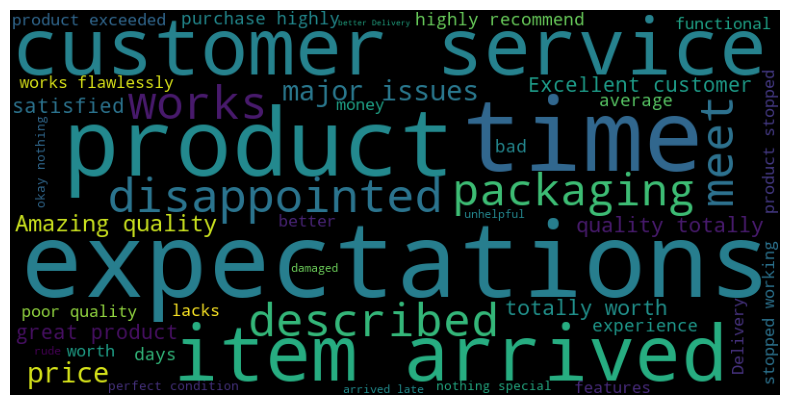

In [33]:
text = " ".join(df['Text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [34]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['cleaned'])

y = df['Label']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [36]:
model = SVC()

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
y_pred = model.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        67
     Neutral       1.00      1.00      1.00        75
    Positive       1.00      1.00      1.00        58

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [40]:
sia = SentimentIntensityAnalyzer()

review = "I absolutely love this product"

score = sia.polarity_scores(review)

score

{'neg': 0.0, 'neu': 0.4, 'pos': 0.6, 'compound': 0.6697}

In [41]:
compound = score['compound']

sentiment_score = int((compound + 1) * 50)

print("Sentiment Quotient:", sentiment_score)

Sentiment Quotient: 83


In [42]:
sample = "Battery life is amazing"

cleaned = preprocess(sample)

vec = vectorizer.transform([cleaned])

prediction = model.predict(vec)[0]

print("Prediction:", prediction)

Prediction: Positive


# Conclusion

The sentiPlus system successfully combines SVM and VADER to create a hybrid sentiment analysis framework capable of generating both sentiment classes and sentiment intensity scores.

The project demonstrates the integration of machine learning, natural language processing, and interactive visualization techniques.